In [8]:
import math
import time
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.model_selection import train_test_split

In [9]:
# ---------------------------
# Utilities & Config
# ---------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparams (tune as required)
EMB_DIM = 2                 # categorical embedding dim (paper used 2)
DIFFUSION_STEPS = 500       # number of diffusion steps
BATCH_SIZE = 512
EPOCHS = 500                # reduce for quick tests; paper used up to 3000
LR = 1e-4
HIDDEN_DIMS = [1024, 1024]  # MLP backbone sizes
BETA_START = 1e-4
BETA_END = 0.02

Using device: cuda:0


In [10]:
# ---------------------------
# Data loading & preprocessing
# ---------------------------
def load_credit_default():
    df = pd.read_csv("/kaggle/input/datasets/toshangupta/adult-dataset/adult.csv")
    print(len(df))
    df.replace('?', np.nan, inplace=True)
    df.dropna(inplace=True)
    print(len(df))
    return df

In [11]:
df = load_credit_default()
print("Loaded shape:", df.shape)
df.columns

48842
45222
Loaded shape: (45222, 15)


Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [12]:
label_col = "income"
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
# df = df[categorical_cols + numeric_cols].copy()
print("Using categorical:", categorical_cols)
print("Using numeric:", numeric_cols)

Using categorical: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')
Using numeric: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [13]:
# Train/test split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=SEED, shuffle=True)

# Numeric preprocessing: quantile transformer
quantile = QuantileTransformer(output_distribution="normal")
train_num = quantile.fit_transform(train_df[numeric_cols].values.astype(float)) if len(numeric_cols) > 0 else np.zeros((len(train_df),0))
test_num = quantile.transform(test_df[numeric_cols].values.astype(float)) if len(numeric_cols) > 0 else np.zeros((len(test_df),0))

# Categorical preprocessing: LabelEncoder per attribute (including label_col)
label_encoders: Dict[str, LabelEncoder] = {}
train_cat_encoded = np.zeros((len(train_df), len(categorical_cols)), dtype=int)
test_cat_encoded = np.zeros((len(test_df), len(categorical_cols)), dtype=int)
vocab_sizes = {}

for i, col in enumerate(categorical_cols):
    le = LabelEncoder()
    train_vals = train_df[col].astype(str).values
    test_vals = test_df[col].astype(str).values
    le.fit(np.concatenate([train_vals, test_vals]))
    label_encoders[col] = le
    train_cat_encoded[:, i] = le.transform(train_vals)
    test_cat_encoded[:, i] = le.transform(test_vals)
    vocab_sizes[col] = len(le.classes_)

# Convert to tensors (note: no separate y label used — label is modeled as categorical input)
x_train_num = torch.tensor(train_num, dtype=torch.float32).to(device)
x_train_cat = torch.tensor(train_cat_encoded, dtype=torch.long).to(device)

x_test_num = torch.tensor(test_num, dtype=torch.float32).to(device)
x_test_cat = torch.tensor(test_cat_encoded, dtype=torch.long).to(device)

train_dataset = TensorDataset(x_train_cat, x_train_num)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

In [14]:
# ---------------------------
# Model building blocks
# ---------------------------
def get_beta_schedule(beta_start: float, beta_end: float, T: int) -> torch.Tensor:
    return torch.linspace(beta_start, beta_end, T, dtype=torch.float32)

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb

class MLPBackbone(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], out_dim: int):
        super().__init__()
        layers = []
        last = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last, h))
            layers.append(nn.GELU())
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    def forward(self, x):
        return self.net(x)

In [15]:
# ---------------------------
# Main synthesizer model
# ---------------------------
class FinDiffSynthesizer(nn.Module):
    def __init__(self,
                 categorical_cols: List[str],
                 vocab_sizes: Dict[str,int],
                 num_continuous: int,
                 cat_emb_dim: int = 2,
                 hidden_dims: List[int] = [1024, 1024]):
        super().__init__()
        self.categorical_cols = categorical_cols
        self.cat_emb_dim = cat_emb_dim

        # Per-attribute embeddings (trainable)
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(num_tokens, cat_emb_dim)
            for col, num_tokens in vocab_sizes.items()
        })

        self.total_cat_dim = len(categorical_cols) * cat_emb_dim
        self.num_continuous = num_continuous
        self.input_dim = self.total_cat_dim + self.num_continuous

        model_dim = max(512, self.input_dim)
        self.input_proj = nn.Linear(self.input_dim, model_dim)

        self.time_emb = SinusoidalPosEmb(64)
        self.time_mlp = nn.Sequential(
            nn.Linear(64, model_dim),
            nn.GELU(),
            nn.Linear(model_dim, model_dim)
        )

        self.backbone = MLPBackbone(input_dim=model_dim, hidden_dims=hidden_dims, out_dim=model_dim)
        self.head = nn.Linear(model_dim, self.input_dim)

    def embed_categoricals(self, cat_idx: torch.LongTensor) -> torch.FloatTensor:
        emb_list = []
        for i, col in enumerate(self.categorical_cols):
            emb = self.embeddings[col](cat_idx[:, i])
            emb_list.append(emb)
        cat_emb = torch.cat(emb_list, dim=-1)
        return cat_emb

    def forward(self, x_cat_idx: torch.LongTensor, x_num: torch.FloatTensor, timesteps: torch.LongTensor):
        cat_emb = self.embed_categoricals(x_cat_idx)
        x = torch.cat([cat_emb, x_num], dim=-1)
        x = self.input_proj(x)
        t_emb = self.time_emb(timesteps)
        t_emb = self.time_mlp(t_emb)
        h = x + t_emb
        h = self.backbone(h)
        out = self.head(h)
        return out

In [16]:
# ---------------------------
# Diffusion helper
# ---------------------------
class DiffusionHelper:
    def __init__(self, betas: torch.Tensor):
        self.device = device
        self.betas = betas.to(self.device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=self.device), self.alphas_cumprod[:-1]])
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.T = len(betas)

    def q_sample(self, x0: torch.Tensor, t: torch.LongTensor, noise: torch.Tensor):
        a_cum = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        one_minus = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return a_cum * x0 + one_minus * noise

    def predict_x0_from_eps(self, xt: torch.Tensor, t: torch.LongTensor, eps: torch.Tensor):
        numer = xt - self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1) * eps
        x0_pred = numer / self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        return x0_pred

    def posterior_variance(self, t: int) -> float:
        return float(self.betas[t] * (1.0 - self.alphas_cumprod_prev[t]) / (1.0 - self.alphas_cumprod[t]))

# helper for sampling: predict eps from flattened embedding+num
def predict_eps_from_emb(xt: torch.Tensor, timesteps: torch.LongTensor, model: FinDiffSynthesizer):
    x_proj = model.input_proj(xt)
    t_emb = model.time_emb(timesteps)
    t_emb = model.time_mlp(t_emb)
    h = x_proj + t_emb
    h = model.backbone(h)
    out = model.head(h)
    return out

In [17]:
# ---------------------------
# Build model, optimizer, schedule
# ---------------------------
synth = FinDiffSynthesizer(
    categorical_cols=categorical_cols,
    vocab_sizes=vocab_sizes,
    num_continuous=len(numeric_cols),
    cat_emb_dim=EMB_DIM,
    hidden_dims=HIDDEN_DIMS
).to(device)

betas = get_beta_schedule(BETA_START, BETA_END, DIFFUSION_STEPS)
diff = DiffusionHelper(betas)
optimizer = torch.optim.Adam(synth.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [18]:

# ---------------------------
# Training loop (no separate y label -- label is one of the categorical inputs)
# ---------------------------
print("Starting training (joint modeling including label)...")
loss_arr=[]
for epoch in range(EPOCHS):
    synth.train()
    epoch_loss = 0.0
    t0 = time.time()
    for batch_cat_idx, batch_num in train_loader:
        batch_size = batch_num.shape[0]
        with torch.no_grad():
            cat_emb = synth.embed_categoricals(batch_cat_idx)
        x0 = torch.cat([cat_emb, batch_num], dim=-1)

        t = torch.randint(low=0, high=diff.T, size=(batch_size,), device=device, dtype=torch.long)
        noise = torch.randn_like(x0, device=device)
        xt = diff.q_sample(x0, t, noise)

        eps_pred = predict_eps_from_emb(xt, t, synth)
        loss = F.mse_loss(eps_pred, noise)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(synth.parameters(), max_norm=5.0)
        optimizer.step()

        epoch_loss += loss.item() * batch_size

    scheduler.step()
    epoch_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} loss: {epoch_loss:.6f} time: {time.time()-t0:.1f}s")
    loss_arr.append(epoch_loss)

print("Training finished.")

Starting training (joint modeling including label)...
Epoch 1/500 loss: 0.521511 time: 1.3s
Epoch 2/500 loss: 0.304324 time: 0.4s
Epoch 3/500 loss: 0.275833 time: 0.4s
Epoch 4/500 loss: 0.261380 time: 0.4s
Epoch 5/500 loss: 0.255646 time: 0.4s
Epoch 6/500 loss: 0.247911 time: 0.4s
Epoch 7/500 loss: 0.240885 time: 0.4s
Epoch 8/500 loss: 0.239020 time: 0.6s
Epoch 9/500 loss: 0.236536 time: 0.4s
Epoch 10/500 loss: 0.232743 time: 0.4s
Epoch 11/500 loss: 0.230521 time: 0.4s
Epoch 12/500 loss: 0.226374 time: 0.4s
Epoch 13/500 loss: 0.223697 time: 0.4s
Epoch 14/500 loss: 0.222157 time: 0.4s
Epoch 15/500 loss: 0.217815 time: 0.4s
Epoch 16/500 loss: 0.212885 time: 0.4s
Epoch 17/500 loss: 0.213018 time: 0.4s
Epoch 18/500 loss: 0.211570 time: 0.4s
Epoch 19/500 loss: 0.210797 time: 0.4s
Epoch 20/500 loss: 0.207213 time: 0.4s
Epoch 21/500 loss: 0.202811 time: 0.4s
Epoch 22/500 loss: 0.203003 time: 0.6s
Epoch 23/500 loss: 0.202617 time: 0.4s
Epoch 24/500 loss: 0.197475 time: 0.4s
Epoch 25/500 loss: 

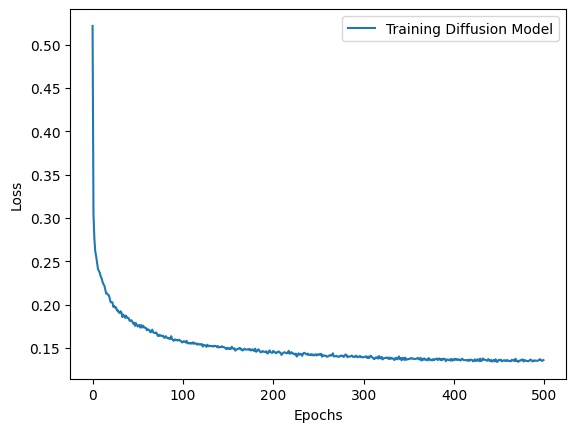

In [19]:
import matplotlib.pyplot as plt

plt.figure()  # ✅ use figure(), not fig()
plt.plot(loss_arr, label="Training Diffusion Model")  # ✅ label goes inside plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()  # ✅ show the label
plt.show()

In [20]:
# ---------------------------
# Sampling loop (joint generation)
# ---------------------------
@torch.no_grad()
def sample_loop(n_samples: int, model: FinDiffSynthesizer, diff_helper: DiffusionHelper):
    model.eval()
    bs = n_samples
    input_dim = model.input_dim
    xt = torch.randn((bs, input_dim), device=device)

    for step in reversed(range(diff_helper.T)):
        t = torch.full((bs,), fill_value=step, device=device, dtype=torch.long)
        eps_pred = predict_eps_from_emb(xt, t, model)

        alpha_t = diff_helper.alphas[step].to(device)
        alpha_cumprod_t = diff_helper.alphas_cumprod[step].to(device)

        sqrt_recip_alpha_t = (1.0 / torch.sqrt(alpha_t)).to(device)
        beta_t = diff_helper.betas[step].to(device)
        coef = (beta_t / torch.sqrt(1.0 - alpha_cumprod_t)).to(device)
        mu_theta = sqrt_recip_alpha_t * (xt - coef.unsqueeze(0) * eps_pred)

        if step > 0:
            posterior_var = diff_helper.posterior_variance(step)
            noise = torch.randn_like(xt)
            xt = mu_theta + math.sqrt(posterior_var) * noise
        else:
            xt = mu_theta
    return xt

n_generate = 45000
generated = sample_loop(n_generate, synth, diff)

In [22]:
# ---------------------------
# Decode generated samples (including label)
# ---------------------------
with torch.no_grad():
    generated = generated.cpu()
    total_cat_dim = synth.total_cat_dim
    cat_emb_flat = generated[:, :total_cat_dim]
    gen_nums = generated[:, total_cat_dim:]

    gen_cat_indices = np.zeros((n_generate, len(categorical_cols)), dtype=int)
    emb_dim = synth.cat_emb_dim
    for i, col in enumerate(categorical_cols):
        start = i * emb_dim
        end = start + emb_dim
        gen_attr_emb = cat_emb_flat[:, start:end].numpy()
        emb_weights = synth.embeddings[col].weight.detach().cpu()
        dists = torch.cdist(torch.tensor(gen_attr_emb, dtype=torch.float32),
                            emb_weights, p=2).numpy()
        nearest = np.argmin(dists, axis=1)
        gen_cat_indices[:, i] = nearest

    # Map indices back to original labels (strings/values)
    gen_cat_str = {}
    for i, col in enumerate(categorical_cols):
        le = label_encoders[col]
        gen_cat_str[col] = le.inverse_transform(gen_cat_indices[:, i])

    # inverse transform numeric
    gen_nums_inv = quantile.inverse_transform(gen_nums.numpy()) if len(numeric_cols) > 0 else np.zeros((n_generate,0))

    # assemble DataFrame; keep order categorical_cols + numeric_cols
    out_df = pd.DataFrame(gen_nums_inv, columns=numeric_cols)
    # put categorical columns first (in same order)
    for i, col in enumerate(categorical_cols):
        out_df[col] = gen_cat_str[col]
    # reorder columns to match desired order (categoricals then numerics)
    #out_df = out_df[categorical_cols + numeric_cols]

    # label_col is present as one of categorical_cols; it will be a column in out_df
    # If label was numeric originally (0/1), try to cast to int
    # try:
    #     out_df[label_col] = out_df[label_col].astype(int)
    # except Exception:
    #     pass

print("Generated synthetic dataframe preview (first 5 rows):")
print(out_df.head())

out_df.to_csv("generated_synthetic_financial_with_label.csv", index=False)
print("Saved generated_synthetic_financial_with_label.csv")

Generated synthetic dataframe preview (first 5 rows):
    age         fnlwgt  educational-num  capital-gain  capital-loss  \
0  23.0  185579.750000             10.0           0.0           0.0   
1  21.0  316152.218750              9.0           0.0           0.0   
2  24.0  135200.015625              9.0           0.0           0.0   
3  47.0  113448.328125              6.0           0.0           0.0   
4  39.0  207679.265625             13.0        7688.0           0.0   

   hours-per-week     workclass     education      marital-status  \
0            30.0       Private  Some-college       Never-married   
1            40.0       Private       HS-grad  Married-civ-spouse   
2            40.0       Private       HS-grad       Never-married   
3            40.0       Private           9th           Separated   
4            70.0  Self-emp-inc     Bachelors  Married-civ-spouse   

          occupation relationship   race  gender native-country income  
0  Handlers-cleaners    Own-chi

In [25]:
torch.save({
    "model_state_dict": synth.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "quantile": quantile,
    "label_encoders": label_encoders,
    "config": {
        "categorical_cols": categorical_cols,
        "vocab_sizes": vocab_sizes,
        "numeric_cols": numeric_cols,
        "emb_dim": EMB_DIM,
        "hidden_dims": HIDDEN_DIMS,
        "diffusion_steps": DIFFUSION_STEPS,
        "beta_start": BETA_START,
        "beta_end": BETA_END
    }
}, "findiff_adult.pth")


# Loading trained model

In [29]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("findiff_adult.pth", map_location=device,weights_only=False)
config = checkpoint["config"]

synth = FinDiffSynthesizer(
    categorical_cols=config["categorical_cols"],
    vocab_sizes=config["vocab_sizes"],
    num_continuous=len(config["numeric_cols"]),
    cat_emb_dim=config["emb_dim"],
    hidden_dims=config["hidden_dims"]
).to(device)
synth.load_state_dict(checkpoint["model_state_dict"])
synth.eval()  # IMPORTANT for inference

optimizer = torch.optim.Adam(synth.parameters(), lr=LR)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
quantile = checkpoint["quantile"]
label_encoders = checkpoint["label_encoders"]
betas = torch.linspace(
    config["beta_start"],
    config["beta_end"],
    config["diffusion_steps"],
    dtype=torch.float32
)

diff = DiffusionHelper(betas)
generated = sample_loop(10, synth, diff)